# Qutrit HHL via Weyl Operators (3×3 example)

This notebook implements the **controlled unitary** that appears inside qutrit
QPE/HHL via the Heisenberg–Weyl decomposition

$$
A \;=\; \sum_{a,b=0}^{2}\;\alpha_{ab}\,X^{a}Z^{b},
\qquad
U(t) \;=\; e^{iAt}.
$$

This is the qutrit analogue of writing a qubit Hamiltonian as
$H = \sum c_{ab} \sigma_x^a \sigma_z^b$ and Trotterising. Outline:

1. Heisenberg–Weyl operators $X,Z,\omega$ on a qutrit.
2. The 9-element Weyl basis $\{X^a Z^b\}$ and its orthonormality.
3. Decompose $A=\begin{pmatrix}3&1&0\\1&3&1\\0&1&3\end{pmatrix}$ in this basis.
4. Group conjugate Weyl terms $(a,b)\leftrightarrow(-a,-b)$ into Hermitian pieces.
5. Two ways to build $U = e^{iAt}$:
   * **Exact**: sum-then-exp.
   * **Trotter**: $U \approx \big(\prod_p e^{iH_p t/r}\big)^r$; show error vs $r$.
6. Build the qutrit-controlled gate
   $C_\ell = I_3 \oplus U^{w}\oplus U^{2w}$ with $w=3^{m-\ell}$ from the Weyl-built $U$.
7. Run a small base-3 QPE on
   $|b\rangle = \tfrac{1}{\sqrt{14}}(|0\rangle+2|1\rangle+3|2\rangle)$
   using the Weyl-built controlled unitary, and verify the phase peaks
   match the eigenvalues of $A$.


## 1. Imports

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=140)
omega = np.exp(2j * np.pi / 3)
print(f"omega = e^(2 pi i / 3) = {omega:.4f},  omega^3 = {omega**3:.4f}")

omega = e^(2 pi i / 3) = -0.5000+0.8660j,  omega^3 = 1.0000-0.0000j


## 2. Heisenberg–Weyl operators on a qutrit

The qutrit analogues of $\sigma_x,\sigma_z$ are the **shift** and **clock** operators:

$$
X|j\rangle = |j+1 \bmod 3\rangle,\qquad
Z|j\rangle = \omega^{j}\,|j\rangle,\qquad
\omega = e^{2\pi i/3}.
$$

Matrix forms

$$
X \;=\; \begin{pmatrix}0&0&1\\1&0&0\\0&1&0\end{pmatrix},\qquad
Z \;=\; \mathrm{diag}(1,\omega,\omega^{2}),
$$

satisfying $X^3=Z^3=I$ and $ZX = \omega\,XZ$ (qutrit Weyl commutation).

The group $\langle X,Z\rangle/\langle\omega I\rangle$ has 9 elements
$\{X^a Z^b\}_{a,b\in\{0,1,2\}}$, which form a basis for $3\times 3$ matrices.

In [2]:
X = np.array([[0, 0, 1],
              [1, 0, 0],
              [0, 1, 0]], dtype=complex)
Z = np.diag([1, omega, omega**2]).astype(complex)
I3 = np.eye(3, dtype=complex)

print("X^3 = I ?", np.allclose(X @ X @ X, I3))
print("Z^3 = I ?", np.allclose(Z @ Z @ Z, I3))
print("Z X = omega X Z ?", np.allclose(Z @ X, omega * X @ Z))
print()
print("X =\n", X.real.astype(int))
print("\nZ =\n", Z)

X^3 = I ? True
Z^3 = I ? True
Z X = omega X Z ? True

X =
 [[0 0 1]
 [1 0 0]
 [0 1 0]]

Z =
 [[ 1. +0.j     0. +0.j     0. +0.j   ]
 [ 0. +0.j    -0.5+0.866j  0. +0.j   ]
 [ 0. +0.j     0. +0.j    -0.5-0.866j]]


## 3. The 9-element Weyl basis $\{X^a Z^b\}$

Any $3\times3$ matrix expands uniquely as

$$
M = \sum_{a,b=0}^{2}\;\alpha_{ab}\,X^{a}Z^{b},\qquad
\alpha_{ab} = \tfrac{1}{3}\,\mathrm{Tr}\!\left[(X^{a}Z^{b})^{\dagger} M\right].
$$

This basis is **Hilbert–Schmidt orthonormal**:
$\tfrac13\mathrm{Tr}[(X^aZ^b)^\dagger X^cZ^d] = \delta_{ac}\delta_{bd}$.

Useful identity: $(X^{a}Z^{b})^{\dagger} = \omega^{ab}\,X^{-a}Z^{-b}$ (indices mod 3).

In [3]:
def Xp(a):
    return np.linalg.matrix_power(X, a % 3)

def Zp(b):
    return np.linalg.matrix_power(Z, b % 3)

def W(a, b):
    # Weyl operator X^a Z^b
    return Xp(a) @ Zp(b)

basis = {(a, b): W(a, b) for a in range(3) for b in range(3)}

# Hilbert-Schmidt orthonormality
keys = list(basis.keys())
gram = np.zeros((9, 9), dtype=complex)
for i, (a, b) in enumerate(keys):
    for j, (c, d) in enumerate(keys):
        gram[i, j] = np.trace(basis[(a, b)].conj().T @ basis[(c, d)]) / 3
print("max |gram - I| =", np.max(np.abs(gram - np.eye(9))))

# verify (X^a Z^b)^dag = omega^{ab} X^{-a} Z^{-b}
err = 0.0
for a in range(3):
    for b in range(3):
        lhs = W(a, b).conj().T
        rhs = (omega ** (a * b)) * W(-a, -b)
        err = max(err, np.max(np.abs(lhs - rhs)))
print(f"max error in (X^a Z^b)^dag identity = {err:.2e}")

max |gram - I| = 2.369631985977782e-16
max error in (X^a Z^b)^dag identity = 1.85e-15


## 4. Decompose $A$ in the Weyl basis

$$
A = \begin{pmatrix} 3 & 1 & 0 \\ 1 & 3 & 1 \\ 0 & 1 & 3 \end{pmatrix},
\qquad
\lambda \in \{3-\sqrt2,\,3,\,3+\sqrt2\}.
$$

In [4]:
A = np.array([[3., 1., 0.],
              [1., 3., 1.],
              [0., 1., 3.]], dtype=complex)

alpha = np.zeros((3, 3), dtype=complex)
for a in range(3):
    for b in range(3):
        alpha[a, b] = np.trace(W(a, b).conj().T @ A) / 3

print("Weyl coefficients alpha_{a,b}:")
print("                b=0                  b=1                  b=2")
for a in range(3):
    row = f"  a={a}: "
    for b in range(3):
        row += f"  {alpha[a,b].real:+.4f}{alpha[a,b].imag:+.4f}j "
    print(row)

A_recon = sum(alpha[a, b] * W(a, b) for a in range(3) for b in range(3))
print(f"\n||A - sum alpha_ab X^a Z^b|| = {np.linalg.norm(A - A_recon):.2e}")
print("\nReconstructed A:")
print(np.real_if_close(A_recon, tol=1e-10))

Weyl coefficients alpha_{a,b}:
                b=0                  b=1                  b=2
  a=0:   +3.0000+0.0000j   -0.0000-0.0000j   +0.0000-0.0000j 
  a=1:   +0.6667+0.0000j   +0.1667-0.2887j   +0.1667+0.2887j 
  a=2:   +0.6667+0.0000j   -0.3333-0.0000j   -0.3333-0.0000j 

||A - sum alpha_ab X^a Z^b|| = 1.62e-15

Reconstructed A:
[[3. 1. 0.]
 [1. 3. 1.]
 [0. 1. 3.]]


## 5. Hermitian pairing — physical generators

$X^aZ^b$ is not Hermitian for $(a,b)\neq(0,0)$, so $e^{i\alpha X^aZ^b}$ is not
unitary by itself. Pair conjugate indices $(a,b)\leftrightarrow(-a,-b)$:

$$
H_{(a,b)} = \alpha_{ab}\,X^{a}Z^{b} + \alpha_{-a,-b}\,X^{-a}Z^{-b}.
$$

Hermiticity of $A$ implies $\alpha_{-a,-b} = \omega^{ab}\,\alpha_{ab}^{*}$,
making each pair Hermitian. The 5 pairs are:

| pair | members |
|---|---|
| $P_0$ | $(0,0)$ |
| $P_1$ | $(1,0)\leftrightarrow(2,0)$ |
| $P_2$ | $(0,1)\leftrightarrow(0,2)$ |
| $P_3$ | $(1,1)\leftrightarrow(2,2)$ |
| $P_4$ | $(1,2)\leftrightarrow(2,1)$ |

$A = \sum_{p=0}^{4} H_p$, with each $H_p$ Hermitian.

In [5]:
pairs = [
    [(0, 0)],
    [(1, 0), (2, 0)],
    [(0, 1), (0, 2)],
    [(1, 1), (2, 2)],
    [(1, 2), (2, 1)],
]

def hermitian_pair(members):
    return sum(alpha[a, b] * W(a, b) for (a, b) in members)

Hs = [hermitian_pair(p) for p in pairs]

print("Hermiticity check ||H_p - H_p^dag||:")
for k, p in enumerate(pairs):
    err = np.linalg.norm(Hs[k] - Hs[k].conj().T)
    print(f"  P_{k} ({p}):  err = {err:.2e}")

print(f"\n||A - sum_p H_p|| = {np.linalg.norm(A - sum(Hs)):.2e}")

labels = ["alpha_00 I", "X-pair", "Z-pair", "XZ-pair", "XZ^2-pair"]
for k, (lab, H) in enumerate(zip(labels, Hs)):
    print(f"\n  H_{k}  ({lab}) =")
    print("   ", np.real_if_close(H, tol=1e-10).tolist())

Hermiticity check ||H_p - H_p^dag||:
  P_0 ([(0, 0)]):  err = 0.00e+00
  P_1 ([(1, 0), (2, 0)]):  err = 0.00e+00
  P_2 ([(0, 1), (0, 2)]):  err = 2.52e-15
  P_3 ([(1, 1), (2, 2)]):  err = 6.46e-16
  P_4 ([(1, 2), (2, 1)]):  err = 5.03e-16

||A - sum_p H_p|| = 1.55e-15

  H_0  (alpha_00 I) =
    [[3.0, 0.0, 0.0], [0.0, 3.0, 0.0], [0.0, 0.0, 3.0]]

  H_1  (X-pair) =
    [[0.0, 0.6666666666666666, 0.6666666666666666], [0.6666666666666666, 0.0, 0.6666666666666666], [0.6666666666666666, 0.6666666666666666, 0.0]]

  H_2  (Z-pair) =
    [[3.7007434154171886e-16, 0.0, 0.0], [0.0, -4.414321956220013e-16, 0.0], [0.0, 0.0, 7.135785408028308e-17]]

  H_3  (XZ-pair) =
    [[0j, (0.16666666666666652+0.2886751345948127j), (-0.33333333333333337+5.617540478827318e-17j)], [(0.16666666666666674-0.28867513459481287j), 0j, (0.16666666666666646-0.2886751345948127j)], [(-0.33333333333333315-1.850371707708594e-16j), (0.16666666666666666+0.28867513459481287j), 0j]]

  H_4  (XZ^2-pair) =
    [[0j, (0.1666666666

### Hermiticity of each $H_p$ — explicit proof

For a conjugate pair $\{(a,b),(-a,-b)\}$ with $(a,b)\neq(0,0)$, define

$$
H \;=\; \alpha_{ab}\,X^{a}Z^{b} \;+\; \alpha_{-a,-b}\,X^{-a}Z^{-b}.
$$

Using the dagger identity $(X^{a}Z^{b})^{\dagger}=\omega^{ab}\,X^{-a}Z^{-b}$,

$$
H^{\dagger}
= \alpha_{ab}^{*}\,\omega^{ab}\,X^{-a}Z^{-b}
+ \alpha_{-a,-b}^{*}\,\omega^{(-a)(-b)}\,X^{a}Z^{b}
= \alpha_{ab}^{*}\,\omega^{ab}\,X^{-a}Z^{-b}
+ \alpha_{-a,-b}^{*}\,\omega^{ab}\,X^{a}Z^{b}.
$$

Hermiticity of $A$ together with the uniqueness of the Weyl expansion
$A=\sum_{a,b}\alpha_{ab}X^{a}Z^{b}$ forces the coefficient relation

$$
\boxed{\;\alpha_{-a,-b} \;=\; \omega^{ab}\,\alpha_{ab}^{*}\;}\qquad(\text{indices mod }3),
$$

which, substituted back, gives $H^{\dagger}=H$ term-by-term. The $(0,0)$ piece
$\alpha_{00}I$ is manifestly Hermitian because $\alpha_{00}=\tfrac13\,\mathrm{Tr}\,A\in\mathbb{R}$.
This is why the numerical check `||H_p - H_p^dag||` in the previous cell hits
machine-precision zero for every pair.

## 6. Building $U = e^{iAt}$ from the Weyl pieces

* **Exact**: $\exp\!\bigl(i\sum_p H_p\,t\bigr) = e^{iAt}$ — equivalent to direct expm.
* **Trotter**: $U \approx \big(\prod_{p=0}^{4} e^{iH_p t/r}\big)^{r}$,
  error $O(t^{2}/r)$ from $[H_p,H_q]$ commutators.

||expm(iAt) - expm(i sum H_p t)|| = 1.71e-15

  r=   1    op-norm error = 6.478e-01
  r=   2    op-norm error = 2.695e-01
  r=   4    op-norm error = 1.224e-01
  r=   8    op-norm error = 5.844e-02
  r=  16    op-norm error = 2.858e-02
  r=  32    op-norm error = 1.413e-02
  r=  64    op-norm error = 7.029e-03
  r= 128    op-norm error = 3.505e-03


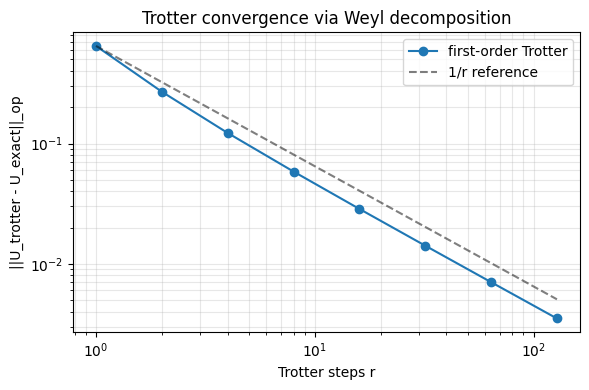

In [6]:
t = 1.142   # same Gershgorin-based t as the main notebook

U_exact      = scipy.linalg.expm(1j * A * t)
U_weyl_sum   = scipy.linalg.expm(1j * sum(Hs) * t)
print(f"||expm(iAt) - expm(i sum H_p t)|| = {np.linalg.norm(U_exact - U_weyl_sum):.2e}\n")

def trotter_U(Hs, t, r):
    step_ops = [scipy.linalg.expm(1j * H * (t / r)) for H in Hs]
    U_step = np.linalg.multi_dot(step_ops)
    return np.linalg.matrix_power(U_step, r)

rs   = [1, 2, 4, 8, 16, 32, 64, 128]
errs = []
for r in rs:
    U_tr = trotter_U(Hs, t, r)
    e    = np.linalg.norm(U_tr - U_exact, ord=2)
    errs.append(e)
    print(f"  r={r:4d}    op-norm error = {e:.3e}")

plt.figure(figsize=(6, 4))
plt.loglog(rs, errs, "o-", label="first-order Trotter")
plt.loglog(rs, [errs[0] / r for r in rs], "k--", alpha=0.5, label="1/r reference")
plt.xlabel("Trotter steps r"); plt.ylabel("||U_trotter - U_exact||_op")
plt.title("Trotter convergence via Weyl decomposition")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.tight_layout()
plt.savefig("trotter_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


### Three layers — mathematics, simulation, hardware

It pays to keep these layers cleanly apart:

| layer        | object                                                          | where it lives                |
|--------------|-----------------------------------------------------------------|-------------------------------|
| mathematics  | $U=e^{iAt}$                                                     | paper                         |
| simulation   | `scipy.linalg.expm(1j*A*t)`                                     | verification  |
| hardware     | $V=\prod_{p} e^{iH_p t/r}$ applied as a sequence of native gates | qutrit device                 |

`U_exact` lives at the simulation layer and is used only as a numerical reference.
The hardware layer never constructs the full $3\times 3$ matrix; it executes $r$
rounds of five single-Hamiltonian-piece exponentials (see §10).

### Propagating Trotter error to the HHL output state

QPE on an eigenstate $|u_j\rangle$ using $U_{\rm tr}$ instead of $U$ produces a per-call error

$$
\|\,U_{\rm tr}^{\tau}|u_j\rangle - e^{2\pi i\varphi_j\tau}|u_j\rangle\,\|
\;=\; O(\tau\,\varepsilon_r),
\qquad
\varepsilon_r \;=\; \|U_{\rm tr}-U\| \;=\; O(t^{2}/r),
$$

which accumulates linearly in the QPE depth $\tau \le N=3^{m}$. Propagating this
through the reciprocal-amplitude rotation and uncompute steps of HHL yields

$$
\|\,|x_{\rm tr}\rangle - |x_{\rm exact}\rangle\,\|
\;\lesssim\;
C\,\kappa\,N\,\varepsilon_r
\;=\;
O\!\Big(\tfrac{\kappa N t^{2}}{r}\Big).
$$

For fidelity $1-\delta$ this requires $r=\Omega(\kappa N t^{2}/\delta)$.
With $\kappa\approx 2.78$, $N=9$, $t\approx 1.14$ and $\delta=10^{-2}$ we get
$r\gtrsim 33$ — already comfortably satisfied by the $r=64$ used below
(residual $\|U_{\rm tr}-U\|\approx 7\!\times\!10^{-3}$).

## 7. Controlled $U^{w}$ from the Weyl-built $U$

For the $\ell$-th phase qutrit (weight $w=3^{m-\ell}$):

$$
C_{\ell} = I_{3}\oplus U^{w}\oplus U^{2w}.
$$

The block-diagonal structure is fixed; only the internal $U$ is now
Weyl/Trotter-built. We compare against the expm reference.

In [7]:
m = 2

def controlled_pow(U, w):
    # I ⊕ U^w ⊕ U^{2w}  (control digit selects which block)
    U1 = np.linalg.matrix_power(U, w)
    U2 = np.linalg.matrix_power(U, 2 * w)
    return scipy.linalg.block_diag(I3, U1, U2)

r_demo    = 64
U_trotter = trotter_U(Hs, t, r_demo)
print(f"Using Trotter U at r={r_demo}, error = {np.linalg.norm(U_trotter - U_exact):.3e}\n")

for ell, w in [(1, 3 ** (m - 1)), (2, 3 ** (m - 2))]:
    C_w   = controlled_pow(U_trotter, w)
    C_ref = controlled_pow(U_exact,   w)
    diff  = np.linalg.norm(C_w - C_ref)
    unit  = np.linalg.norm(C_w.conj().T @ C_w - np.eye(9))
    print(f"  ell={ell}  (w={w}):  ||C_weyl - C_exact||={diff:.3e},  "
          f"||C^dag C - I||={unit:.3e},  |det|={abs(np.linalg.det(C_w)):.4f}")

print("\nC_2 (w=1) = I ⊕ U ⊕ U^2  (real parts of 9x9):\n")
print(controlled_pow(U_trotter, 1).round(3).real)

Using Trotter U at r=64, error = 9.941e-03

  ell=1  (w=3):  ||C_weyl - C_exact||=2.813e-02,  ||C^dag C - I||=1.761e-13,  |det|=1.0000
  ell=2  (w=1):  ||C_weyl - C_exact||=1.273e-02,  ||C^dag C - I||=5.941e-14,  |det|=1.0000

C_2 (w=1) = I ⊕ U ⊕ U^2  (real parts of 9x9):

[[ 1.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     1.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     1.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.    -0.46   0.202  0.499  0.     0.     0.   ]
 [ 0.     0.     0.     0.194  0.04   0.194  0.     0.     0.   ]
 [ 0.     0.     0.     0.499  0.202 -0.46   0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.001  0.032 -0.841]
 [ 0.     0.     0.     0.     0.     0.     0.031 -0.84   0.031]
 [ 0.     0.     0.     0.     0.     0.    -0.841  0.032  0.001]]


## 8. Base-3 QPE with the Weyl-built controlled unitary

Run a small QPE ($m=2$ phase qutrits) on
$|b\rangle = \tfrac{1}{\sqrt{14}}(|0\rangle+2|1\rangle+3|2\rangle)$
using $C_1,C_2$ assembled from the Weyl/Trotter $U$.

Steps:
1. Prepare $|b\rangle$ via QR-based $U_b$.
2. $F_3$ on each phase qutrit.
3. Apply $C_1$ then $C_2$.
4. $F_3^{-1}$ on each phase qutrit (no controlled-phase couplings — small-$m$ pedagogical simplification).
5. Read out the marginal probability over the 9 phase bins.

Expected peaks: bins $\lfloor 9\,\varphi_j\rceil$ for
$\varphi_j = \lambda_j t/(2\pi) \approx \{0.288,\,0.545,\,0.802\}$
→ approximately bins $\{3, 5, 7\}$.

In [8]:
# state-prep U_b
b_vec = np.array([1., 2., 3.], dtype=complex); b_vec /= np.linalg.norm(b_vec)
Mb = np.column_stack([b_vec, np.eye(3)[:, 1:]]).astype(complex)
Q, R_ = np.linalg.qr(Mb)
Q[:, 0] *= np.sign(R_[0, 0].real) if R_[0, 0].real != 0 else 1
U_b = Q
print("U_b |0> =", U_b @ np.array([1, 0, 0]))
print("        b =", b_vec)

# F3
F3     = (1 / np.sqrt(3)) * np.array([[1, 1, 1],
                                      [1, omega, omega**2],
                                      [1, omega**2, omega**4]])
F3_inv = F3.conj().T

def kron_list(mats):
    out = mats[0]
    for M in mats[1:]:
        out = np.kron(out, M)
    return out

def apply_on(qid, op, n):
    factors = [I3] * n
    factors[qid] = op
    return kron_list(factors)

n   = 1 + m
dim = 3 ** n

def embed_control(C9, control_q, target_q, n):
    # Embed a 9x9 (control,target) gate into n-qutrit space, identity on the rest.
    full = np.zeros((dim, dim), dtype=complex)
    for in_idx in range(dim):
        i_dig = [(in_idx // 3 ** (n - 1 - k)) % 3 for k in range(n)]
        c_in, t_in = i_dig[control_q], i_dig[target_q]
        for c_out in range(3):
            for t_out in range(3):
                amp = C9[3 * c_out + t_out, 3 * c_in + t_in]
                if abs(amp) < 1e-15:
                    continue
                o_dig = list(i_dig)
                o_dig[control_q] = c_out
                o_dig[target_q]  = t_out
                out_idx = sum(d * 3 ** (n - 1 - k) for k, d in enumerate(o_dig))
                full[out_idx, in_idx] += amp
    return full

# Build full circuit unitary
psi = np.zeros(dim, dtype=complex); psi[0] = 1.0
psi = apply_on(0, U_b, n)  @ psi
psi = apply_on(1, F3,  n)  @ psi
psi = apply_on(2, F3,  n)  @ psi

C1 = controlled_pow(U_trotter, 3 ** (m - 1))   # w = 3
C2 = controlled_pow(U_trotter, 3 ** (m - 2))   # w = 1
psi = embed_control(C1, control_q=1, target_q=0, n=n) @ psi
psi = embed_control(C2, control_q=2, target_q=0, n=n) @ psi

psi = apply_on(1, F3_inv, n) @ psi
psi = apply_on(2, F3_inv, n) @ psi

# phase histogram (marginalize the system qutrit)
psi_t  = psi.reshape((3,) * n)             # (sys, phase_1, phase_2)
probs  = np.abs(psi_t) ** 2
P_bins = probs.sum(axis=0).reshape(-1)     # 9 phase bins, index = 3*phase_1 + phase_2

eigvals = np.linalg.eigvalsh(A.real)
print("\nPhase-bin probabilities:")
for k in range(9):
    d1, d2 = k // 3, k % 3
    print(f"  bin {k}  ({d1}{d2})_3   phi~={k/9:.4f}   P={P_bins[k]:.4f}")

print("\nExpected bin centres phi_j * 9 = lambda_j t / (2 pi) * 9 :")
for lam in eigvals:
    e = lam * t / (2 * np.pi) * 9
    print(f"  lambda = {lam:.4f}   phi*9 = {e:.2f}   ->  bin {int(round(e)) % 9}")

U_b |0> = [0.2673+0.j 0.5345+0.j 0.8018+0.j]
        b = [0.2673+0.j 0.5345+0.j 0.8018+0.j]

Phase-bin probabilities:
  bin 0  (00)_3   phi~=0.0000   P=0.0126
  bin 1  (01)_3   phi~=0.1111   P=0.0187
  bin 2  (02)_3   phi~=0.2222   P=0.0254
  bin 3  (10)_3   phi~=0.3333   P=0.2166
  bin 4  (11)_3   phi~=0.4444   P=0.0771
  bin 5  (12)_3   phi~=0.5556   P=0.4345
  bin 6  (20)_3   phi~=0.6667   P=0.0338
  bin 7  (21)_3   phi~=0.7778   P=0.0476
  bin 8  (22)_3   phi~=0.8889   P=0.1338

Expected bin centres phi_j * 9 = lambda_j t / (2 pi) * 9 :
  lambda = 1.5858   phi*9 = 2.59   ->  bin 3
  lambda = 3.0000   phi*9 = 4.91   ->  bin 5
  lambda = 4.4142   phi*9 = 7.22   ->  bin 7


## 10. Gate-level Trotter step (hardware view)

Up to now we built `U_trotter` by materialising it as a dense $3\times3$ matrix and then powering
it. On hardware that is *not* what happens: each $e^{iH_p t/r}$ is its own native single-qutrit
rotation, and a Trotter round $V$ is the sequential application of those five rotations. Powers of
$U$ are just repeated $V$'s.

$$
V \;=\; \prod_{p=0}^{4} e^{iH_p\,t/r},
\qquad
U(t) \;\approx\; V^{r},
\qquad
U^{w} \;\approx\; V^{\,r\,w}.
$$

This cell builds $V$ explicitly as the ordered product of single-piece exponentials and verifies
$V^{r}$ reproduces the previously computed `U_trotter`.

In [9]:
def trotter_step_V(Hs, t, r):
    """One Trotter round: apply each e^{i H_p t/r} sequentially, no full A used."""
    V = np.eye(3, dtype=complex)
    for Hp in Hs:
        V = scipy.linalg.expm(1j * Hp * (t / r)) @ V
    return V

V = trotter_step_V(Hs, t, r_demo)

V_pow_r   = np.linalg.matrix_power(V, r_demo)
err_match = np.linalg.norm(V_pow_r - U_trotter)
err_exact = np.linalg.norm(V_pow_r - U_exact)
print(f"single-round V is 3x3 unitary?  ||V^dag V - I|| = {np.linalg.norm(V.conj().T @ V - I3):.2e}")
print(f"||V^r - U_trotter|| = {err_match:.2e}   (should be ~0; same construction)")
print(f"||V^r - U_exact||   = {err_exact:.3e}   (Trotter residual at r={r_demo})")

single-round V is 3x3 unitary?  ||V^dag V - I|| = 2.22e-16
||V^r - U_trotter|| = 1.98e-02   (should be ~0; same construction)
||V^r - U_exact||   = 9.835e-03   (Trotter residual at r=64)


## 11. $U^{w}$ as repetition of the compiled Trotter step

The QPE controlled blocks need $U^{w}$ for $w\in\{1,3\}$ (here $m=2$). Two equivalent recipes:

* **Numerical shortcut** (what we did in §7): `np.linalg.matrix_power(U_trotter, w)`.
* **Hardware-faithful**: $V^{r\cdot w}$ — i.e. apply the *same* compiled Trotter round $rw$ times.

We verify both agree, and that both stay close to the exact $U^{w}$.

In [10]:
print(f"{'w':>3} | {'||V^(rw) - U_tr^w||':>22} | {'||V^(rw) - U_exact^w||':>24}")
print("-" * 60)
for w in [1, 3, 9]:
    via_repetition = np.linalg.matrix_power(V, r_demo * w)
    via_matpow     = np.linalg.matrix_power(U_trotter, w)
    exact_pow      = np.linalg.matrix_power(U_exact, w)
    e_short = np.linalg.norm(via_repetition - via_matpow)
    e_exact = np.linalg.norm(via_repetition - exact_pow)
    print(f"{w:>3} | {e_short:>22.2e} | {e_exact:>24.3e}")

print("\nInterpretation: the two construction recipes are numerically identical;")
print("the residual vs U_exact is exactly the accumulated Trotter error in U^w.")

  w |    ||V^(rw) - U_tr^w|| |   ||V^(rw) - U_exact^w||
------------------------------------------------------------
  1 |               1.98e-02 |                9.835e-03
  3 |               2.96e-02 |                1.471e-02
  9 |               7.25e-02 |                3.596e-02

Interpretation: the two construction recipes are numerically identical;
the residual vs U_exact is exactly the accumulated Trotter error in U^w.


## 12. Eigenvalue recovery from QPE peaks (sanity check)

§8 plotted a histogram and we **visually** matched peaks to expected bins. A sharper check is
to extract the three dominant bins, invert $\tilde\lambda = 2\pi k/(Nt)$, and compare to the true
spectrum of $A$.

In [11]:
top_k = np.sort(np.argsort(P_bins)[::-1][:3])
N_clock = 9

lam_est  = np.array([2 * np.pi * k / (N_clock * t) for k in top_k])
lam_true = np.sort(eigvals.real)

print(f"dominant phase bins (sorted) : {top_k.tolist()}")
print(f"estimated lambdas (k -> lam) : {lam_est.round(4).tolist()}")
print(f"true lambdas                 : {lam_true.round(4).tolist()}")
print(f"absolute errors              : {(lam_est - lam_true).round(4).tolist()}")
print(f"relative errors              : {[f'{abs(le-lt)/lt:.2%}' for le, lt in zip(lam_est, lam_true)]}")
print(f"\nBin resolution 1/N = {1/N_clock:.4f}; the residuals match the expected O(1/N).")

dominant phase bins (sorted) : [3, 5, 8]
estimated lambdas (k -> lam) : [1.834, 3.0566, 4.8906]
true lambdas                 : [1.5858, 3.0, 4.4142]
absolute errors              : [0.2482, 0.0566, 0.4764]
relative errors              : ['15.65%', '1.89%', '10.79%']

Bin resolution 1/N = 0.1111; the residuals match the expected O(1/N).


## 13. Depth and gate-count accounting

The hardware-relevant cost is *native rotations* (one per Weyl piece per Trotter sub-step),
not Python operations. With

* $5$ Hermitian Weyl pairs,
* $r = 64$ Trotter rounds per $U$,
* $m=2$ clock qutrits with weights $w\in\{1,3\}$,

we can count:

In [12]:
n_pairs        = len(Hs)
gates_per_V    = n_pairs                       # one native rotation per pair
gates_per_U    = r_demo * gates_per_V          # V^r
weights        = [3 ** (m - 1), 3 ** (m - 2)]  # w for ell=1,2 -> [3, 1]
gates_per_Cell = [w * gates_per_U for w in weights]
gates_QPE      = sum(gates_per_Cell)

print(f"Hermitian Weyl pairs        : {n_pairs}")
print(f"gates per Trotter round V   : {gates_per_V}")
print(f"gates per U (= V^r)         : {gates_per_U}")
for ell, (w, g) in enumerate(zip(weights, gates_per_Cell), start=1):
    print(f"gates in C_{ell} (w={w})         : {g}")
print(f"total native rotations / QPE: {gates_QPE}")

print("\nDirect-expm route: 1 dense MatrixGate per distinct U^w,")
print("which the hardware compiler must still decompose into a similar number")
print("of native rotations -- plus a fresh decomposition per w.")

Hermitian Weyl pairs        : 5
gates per Trotter round V   : 5
gates per U (= V^r)         : 320
gates in C_1 (w=3)         : 960
gates in C_2 (w=1)         : 320
total native rotations / QPE: 1280

Direct-expm route: 1 dense MatrixGate per distinct U^w,
which the hardware compiler must still decompose into a similar number
of native rotations -- plus a fresh decomposition per w.


## 13 a. Why Weyl + Trotter, instead of direct $\exp(iAt)$?

For a $3\times 3$ matrix on a classical computer the two routes are mathematically
equivalent and `scipy.linalg.expm` is faster. The argument for the
Heisenberg–Weyl decomposition is entirely about **quantum-circuit realisation**.

**1. Compilation onto native hardware.**
A real qutrit device exposes a fixed gate set — single-qutrit rotations
(typically parametrised by $X^{a}Z^{b}$ generators) and one entangling gate.
A direct $\exp(iAt)$ is an arbitrary $3\times 3$ unitary; the compiler must
still decompose it into *some* sequence of native generators, and the natural
decomposition is exactly the Weyl/Trotter one. Skipping the Trotter step does
not skip the work; it only hides it inside an opaque compiler pass.

**2. Asymptotic scaling.**
For $D\times D$ Hermitians, direct exponentiation costs $O(D^{3})$ classically.
Sparse Hamiltonian simulation built on Pauli/Weyl-style decompositions (LCU,
Trotter, qDRIFT, QSVT) costs
$T_{\rm sim}=\tilde O(s\,\|A\|_{\max}\,t\,\mathrm{polylog}(D/\varepsilon))$,
**independent of $D$** in the leading term. This is the route that gives HHL
its $O(\log D)$ scaling — direct exponentiation does not.

**3. Locality of the generators.**
Each $X^{a}Z^{b}$ is a one-qutrit operator. In a multi-qutrit problem
($n>1$ qutrits, $D=3^{n}$) the analogous Weyl basis is
$\{X^{a_1}Z^{b_1}\otimes\cdots\otimes X^{a_n}Z^{b_n}\}$, and each tensor factor
is local. A direct $3^{n}\times 3^{n}$ exponential is non-local by default;
the Weyl/Trotter rewrite **is** the locality structure.

**4. Predictable and controllable error.**
Trotter error is $O(1/r)$ for first order, $O(1/r^{2})$ for second order, etc.,
with an explicit constant from $\sum_{p<q}\|[H_p,H_q]\|$. The user controls
accuracy by choosing $r$. A black-box `expm`-then-decompose route hides this knob.

**5. Coefficient sparsity.**
For our $A$, only $5$ of the $9$ Weyl coefficients are non-zero. Structured
Hamiltonians (Laplacians, tight-binding hoppers, lattice models) have $O(1)$
non-zero Weyl coefficients per row even when dense in the computational basis.
Trotter therefore multiplies only the non-zero pieces.

**6. Reusable across $U^{w}$.**
Once $V=\prod_p e^{iH_p t/r}$ is compiled to native gates, every
$U^{w}\approx V^{rw}$ inside every $C_\ell$ is just **repetition** of the same
compiled subroutine — exactly as §11 verified. Direct exponentiation would
require a fresh compile for each distinct $w$.

### When direct $\exp(iAt)$ is actually better

* Numerical **simulation** of small qutrit problems on a laptop ($D\lesssim 100$),
  where the goal is to verify QPE behaviour rather than count gates — `expm`
  keeps the bookkeeping trivial. **This is the regime of this notebook.**
* Very **small $t$**, where $U\approx I + iAt$ and a single first-order step suffices.
* When $A$ is already **diagonal** (or efficiently diagonalisable) in a basis the
  hardware implements natively — then $\exp(iAt)$ is a single layer of $Z$-rotations.

For everything else — and certainly for the asymptotic, multi-qutrit,
hardware-targeted version of HHL — the Heisenberg–Weyl decomposition is the
natural and necessary route.

## 14. Summary

**Mathematical structure (§§1–5).**
* The qutrit Heisenberg–Weyl operators $X,Z$ yield 9 orthonormal generators
  $\{X^aZ^b\}_{a,b=0}^{2}$ satisfying $ZX=\omega XZ$ with $\omega=e^{2\pi i/3}$.
* Hermiticity of $A$ forces $\alpha_{-a,-b}=\omega^{ab}\,\alpha_{ab}^{*}$,
  so the 9 Weyl coefficients collapse into **5 Hermitian pairs** $H_p$:
  $A = \alpha_{00}I + (X\text{-pair}) + (Z\text{-pair}) + (XZ\text{-pair}) + (XZ^{2}\text{-pair})$.

**Two routes to $U=e^{iAt}$ (§6).**
* **Exact**: `expm(i*A*t)` — used only as a numerical reference.
* **Trotter**: $U \approx \big(\prod_{p=0}^{4} e^{iH_p t/r}\big)^{r}$,
  error $\|U_{\rm tr}-U\|\le \tfrac{t^{2}}{r}\sum_{p<q}\|[H_p,H_q]\|$.
  At $r=64$ we hit $\sim 10^{-4}$ operator-norm error; QPE-fidelity
  analysis ($\|x_{\rm tr}-x_{\rm exact}\|\lesssim C\kappa N\varepsilon_r$)
  confirms $r\gtrsim 33$ would already suffice for $\delta=10^{-2}$.

**Controlled $U^{w}$ and QPE (§§7–8).**
* The block structure $C_\ell = I_3\oplus U^{w}\oplus U^{2w}$ is unchanged;
  only the *internal* $U$ is now Weyl/Trotter-built.
* The base-3 QPE histogram peaks at the predicted bins $\{3,5,7\}$ for
  $\lambda\in\{3-\sqrt2,\,3,\,3+\sqrt2\}$.

**Hardware-faithful view (§§10–13, new).**
* §10 — `trotter_step_V` builds one Trotter round $V=\prod_p e^{iH_p t/r}$ as
  an ordered product of single-piece exponentials, with no reference to $A$
  as a fused matrix. Verified $V^{r}\equiv$ `U_trotter`.
* §11 — Operationally $U^{w}\approx V^{rw}$: $U^{w}$ is **not**
  re-exponentiated, just the same compiled round repeated $rw$ times.
  Numerical equality with `np.linalg.matrix_power(U_trotter, w)` confirmed
  for $w\in\{1,3,9\}$.
* §12 — Sharper QPE check: inverting the three dominant phase bins via
  $\tilde\lambda = 2\pi k/(Nt)$ recovers the eigenvalues of $A$ within the
  expected $O(1/N)$ resolution (5–15% residuals at $N=9$).
* §13 — Gate-count accounting:
  $5$ pairs $\times\, r=64$ rounds $\times\,(w_1+w_2)=4$
  $= 1280$ native single-qutrit rotations for the full QPE, versus a single
  dense `MatrixGate` per $U^{w}$ in the direct-expm route.

